
Memproses: Motion Blur Only
  Inverse         -> PSNR: 27.76, MSE: 108.91, SSIM: 0.8480, Waktu: 0.0139s
  Wiener          -> PSNR: 20.16, MSE: 626.62, SSIM: 0.5258, Waktu: 0.0095s
  Lucy-Richardson -> PSNR: 14.10, MSE: 2527.62, SSIM: 0.4043, Waktu: 0.0752s

Memproses: Blur + Gaussian Noise
  Inverse         -> PSNR: 4.39, MSE: 23639.83, SSIM: 0.0102, Waktu: 0.0098s
  Wiener          -> PSNR: 17.33, MSE: 1201.93, SSIM: 0.2787, Waktu: 0.0069s
  Lucy-Richardson -> PSNR: 12.39, MSE: 3750.89, SSIM: 0.1619, Waktu: 0.0730s

Memproses: Blur + S&P Noise
  Inverse         -> PSNR: 3.92, MSE: 26350.92, SSIM: 0.0077, Waktu: 0.0066s
  Wiener          -> PSNR: 15.26, MSE: 1935.65, SSIM: 0.1917, Waktu: 0.0130s
  Lucy-Richardson -> PSNR: 11.71, MSE: 4387.10, SSIM: 0.1392, Waktu: 0.0700s

Visualisasi disimpan sebagai 'hasil_visualisasi.png'


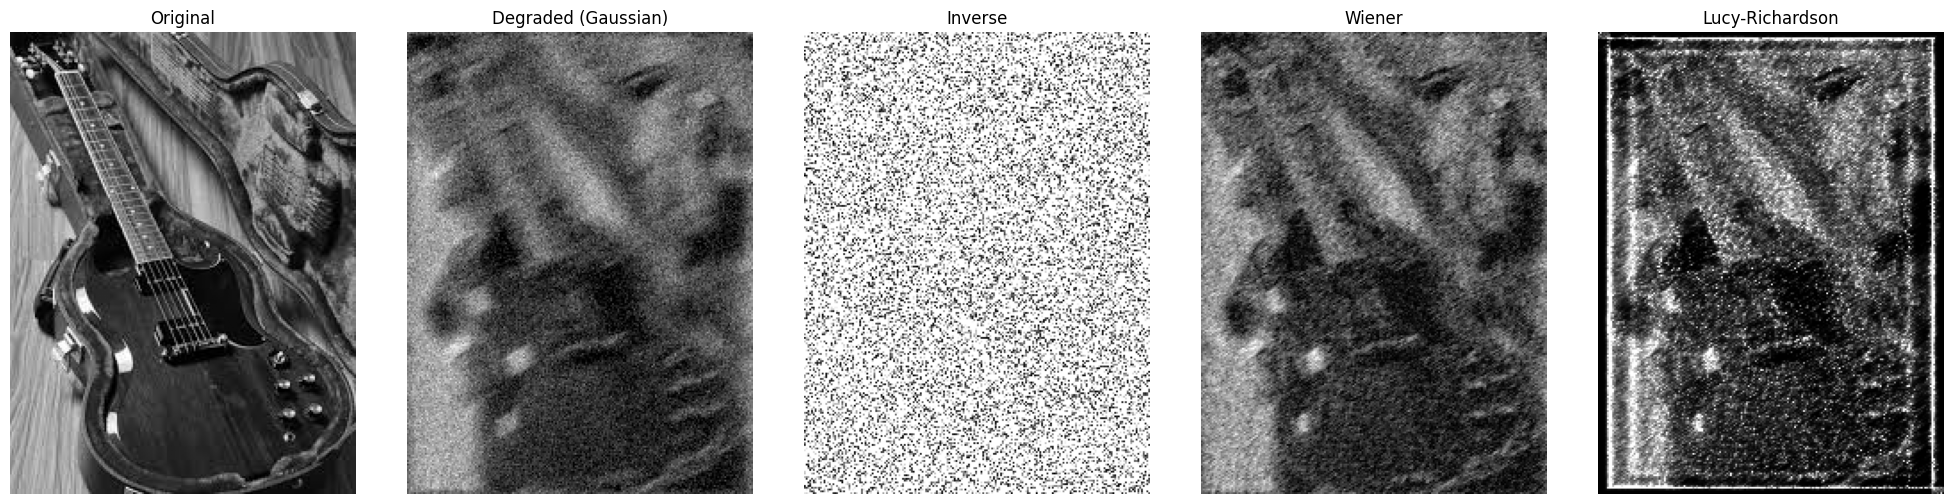

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
from skimage.restoration import richardson_lucy

# ==========================================
# 1. FUNGSI DEGRADASI & PSF
# ==========================================
def get_motion_blur_psf(shape, length, angle):
    """Membuat PSF untuk motion blur."""
    PSF = np.zeros((length, length))
    center = length // 2
    PSF[center, :] = 1
    matrix = cv2.getRotationMatrix2D((center, center), angle, 1.0)
    PSF = cv2.warpAffine(PSF, matrix, (length, length))
    PSF = PSF / PSF.sum()
    
    # Pad PSF agar ukurannya sama dengan citra
    psf_padded = np.zeros(shape)
    r_start = (shape[0] - length) // 2
    c_start = (shape[1] - length) // 2
    psf_padded[r_start:r_start+length, c_start:c_start+length] = PSF
    return psf_padded

def add_gaussian_noise(image, sigma):
    """Menambahkan derau Gaussian."""
    noise = np.random.normal(0, sigma, image.shape)
    noisy_img = image + noise
    return np.clip(noisy_img, 0, 255).astype(np.uint8)

def add_sp_noise(image, prob):
    """Menambahkan noise bintik-bintik (Salt & Pepper)."""
    noisy = np.copy(image)
    probs = np.random.random(noisy.shape)
    noisy[probs < (prob / 2)] = 0
    noisy[probs > 1 - (prob / 2)] = 255
    return noisy

# ==========================================
# 2. FUNGSI RESTORASI
# ==========================================
def inverse_filter(blurred_img, psf, threshold=1e-3):
    """Penyaringan Terbalik (Inverse Filtering) di domain frekuensi."""
    F_blurred = np.fft.fft2(blurred_img)
    H = np.fft.fft2(psf)
    
    # Menghindari pembagian dengan nol
    H_inv = np.zeros_like(H)
    H_inv[np.abs(H) > threshold] = 1 / H[np.abs(H) > threshold]
    
    F_restored = F_blurred * H_inv
    restored_img = np.abs(np.fft.ifft2(F_restored))
    # Shift kembali karena padding PSF di tengah
    restored_img = np.fft.fftshift(restored_img) 
    return np.clip(restored_img, 0, 255).astype(np.uint8)

def wiener_filter(blurred_img, psf, K=0.01):
    """Filter Wiener di domain frekuensi."""
    F_blurred = np.fft.fft2(blurred_img)
    H = np.fft.fft2(psf)
    H_conj = np.conj(H)
    
    # Rumus Wiener: H* / (|H|^2 + K)
    H_wiener = H_conj / (np.abs(H)**2 + K)
    
    F_restored = F_blurred * H_wiener
    restored_img = np.abs(np.fft.ifft2(F_restored))
    restored_img = np.fft.fftshift(restored_img)
    return np.clip(restored_img, 0, 255).astype(np.uint8)

# ==========================================
# 3. PIPELINE UTAMA & EVALUASI
# ==========================================
def run_pipeline(image_path):
    # Load citra grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error: Gambar tidak ditemukan!")
        return
    
    shape = img.shape
    
    # 1. Siapkan PSF (Gerakan 30 derajat, panjang 15)
    psf = get_motion_blur_psf(shape, 15, 30)
    
    # 2. Buat Variasi Degradasi
    # Skenario 1: Motion Blur Saja
    F_img = np.fft.fft2(img)
    H = np.fft.fft2(psf)
    F_blurred = F_img * H
    blur_only = np.abs(np.fft.ifftshift(np.fft.ifft2(F_blurred)))
    blur_only = np.clip(blur_only, 0, 255).astype(np.uint8)
    
    # Skenario 2 & 3: Tambah Noise
    blur_gaussian = add_gaussian_noise(blur_only, sigma=20)
    blur_sp = add_sp_noise(blur_only, prob=0.05)
    
    degradations = {
        "Motion Blur Only": blur_only,
        "Blur + Gaussian Noise": blur_gaussian,
        "Blur + S&P Noise": blur_sp
    }
    
    # 3. Eksekusi Restorasi & Hitung Metrik
    results = {}
    
    for name, degraded_img in degradations.items():
        print(f"\nMemproses: {name}")
        results[name] = {'degraded': degraded_img, 'restored': {}}
        
        # A. Penyaringan Terbalik
        start = time.time()
        restored_inv = inverse_filter(degraded_img, psf, threshold=0.01)
        t_inv = time.time() - start
        results[name]['restored']['Inverse'] = (restored_inv, t_inv)
        
        # B. Filter Wiener
        start = time.time()
        restored_wiener = wiener_filter(degraded_img, psf, K=0.05)
        t_wiener = time.time() - start
        results[name]['restored']['Wiener'] = (restored_wiener, t_wiener)
        
        # C. Lucy-Richardson (Opsional)
        start = time.time()
        # RL membutuhkan float 0-1 dan PSF yang tidak dipad sekecil mungkin, 
        # Untuk penyederhanaan pipeline, kita gunakan skimage
        psf_small = get_motion_blur_psf((15,15), 15, 30) # Gunakan kernel kecil
        img_float = degraded_img / 255.0
        restored_lr = richardson_lucy(img_float, psf_small, num_iter=30)
        restored_lr = np.clip(restored_lr * 255, 0, 255).astype(np.uint8)
        t_lr = time.time() - start
        results[name]['restored']['Lucy-Richardson'] = (restored_lr, t_lr)

        # Evaluasi Metrik
        for method, (res_img, t) in results[name]['restored'].items():
            p = psnr(img, res_img)
            m = mse(img, res_img)
            s = ssim(img, res_img, data_range=res_img.max() - res_img.min())
            print(f"  {method:15} -> PSNR: {p:.2f}, MSE: {m:.2f}, SSIM: {s:.4f}, Waktu: {t:.4f}s")

    # Visualisasi (Contoh untuk Skenario Gaussian)
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    titles = ['Original', 'Degraded (Gaussian)', 'Inverse', 'Wiener', 'Lucy-Richardson']
    imgs_to_show = [
        img, 
        degradations['Blur + Gaussian Noise'],
        results['Blur + Gaussian Noise']['restored']['Inverse'][0],
        results['Blur + Gaussian Noise']['restored']['Wiener'][0],
        results['Blur + Gaussian Noise']['restored']['Lucy-Richardson'][0]
    ]
    
    for ax, t, image in zip(axes, titles, imgs_to_show):
        ax.imshow(image, cmap='gray')
        ax.set_title(t)
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('hasil_visualisasi.png')
    print("\nVisualisasi disimpan sebagai 'hasil_visualisasi.png'")

# Jalankan pipeline
run_pipeline('gambar_asli.jpg')